In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
import matplotlib.patheffects as path_effects
import numpy as np
from collections import defaultdict

def get_image_to_categories(coco):
    """
    Build a mapping from image_id to set of category_ids present in that image.
    """
    image_to_cats = defaultdict(set)
    ann_ids = coco.getAnnIds()
    annotations = coco.loadAnns(ann_ids)
    
    for ann in annotations:
        img_id = ann['image_id']
        cat_id = ann['category_id']
        image_to_cats[img_id].add(cat_id)
    
    return image_to_cats

def greedy_set_cover(image_to_cats, all_categories, exclude_images=None):
    """
    Greedy algorithm to find minimum images covering all categories.
    Returns list of (image_id, categories_covered_by_this_image, cumulative_new_categories).
    """
    if exclude_images is None:
        exclude_images = set()
    
    uncovered = set(all_categories)
    selected_images = []
    
    # Filter out excluded images
    available_images = {k: v for k, v in image_to_cats.items() if k not in exclude_images}
    
    while uncovered and available_images:
        # Find image that covers the most uncovered categories
        best_img = None
        best_coverage = set()
        
        for img_id, cats in available_images.items():
            coverage = cats & uncovered
            if len(coverage) > len(best_coverage):
                best_img = img_id
                best_coverage = coverage
        
        if best_img is None or len(best_coverage) == 0:
            break
        
        selected_images.append((best_img, image_to_cats[best_img], best_coverage))
        uncovered -= best_coverage
        del available_images[best_img]
    
    return selected_images, uncovered

def find_alternative_solutions(image_to_cats, all_categories, num_solutions=3):
    """
    Find multiple near-optimal solutions by using different starting strategies.
    """
    solutions = []
    
    # Solution 1: Pure greedy (optimal approximation)
    sol1, remaining1 = greedy_set_cover(image_to_cats, all_categories)
    solutions.append(("Greedy Optimal", sol1, remaining1))
    
    # Solution 2: Prioritize images with rare categories first
    # Count category frequencies
    cat_freq = defaultdict(int)
    for cats in image_to_cats.values():
        for c in cats:
            cat_freq[c] += 1
    
    # Score images by sum of inverse frequencies (prefer rare categories)
    def rarity_score(img_id):
        return sum(1.0 / cat_freq[c] for c in image_to_cats[img_id])
    
    # Sort images by rarity score and pick greedily from top candidates
    sorted_by_rarity = sorted(image_to_cats.keys(), key=rarity_score, reverse=True)
    
    uncovered = set(all_categories)
    sol2 = []
    for img_id in sorted_by_rarity:
        if not uncovered:
            break
        coverage = image_to_cats[img_id] & uncovered
        if coverage:
            sol2.append((img_id, image_to_cats[img_id], coverage))
            uncovered -= coverage
    solutions.append(("Rare Categories First", sol2, uncovered))
    
    # Solution 3: Diverse selection - after each pick, prefer images with different categories
    uncovered = set(all_categories)
    sol3 = []
    used_cats = set()
    available = dict(image_to_cats)
    
    while uncovered and available:
        best_img = None
        best_score = -1
        best_coverage = set()
        
        for img_id, cats in available.items():
            coverage = cats & uncovered
            if not coverage:
                continue
            # Score: coverage count + bonus for new category types not yet shown
            new_cats = cats - used_cats
            score = len(coverage) + 0.5 * len(new_cats)
            if score > best_score:
                best_score = score
                best_img = img_id
                best_coverage = coverage
        
        if best_img is None:
            break
        
        sol3.append((best_img, image_to_cats[best_img], best_coverage))
        uncovered -= best_coverage
        used_cats |= image_to_cats[best_img]
        del available[best_img]
    
    solutions.append(("Diversity Focused", sol3, uncovered))
    
    return solutions

def plot_solution_images(coco, solution, image_folder, dataset_name, solution_name):
    """
    Plot all images from a solution with bounding boxes and class labels.
    Creates a single figure with subplots AND saves each image individually.
    """
    num_images = len(solution)
    
    # Determine grid size
    if num_images <= 3:
        rows, cols = 1, num_images
    elif num_images <= 6:
        rows, cols = 2, 3
    elif num_images <= 9:
        rows, cols = 3, 3
    elif num_images <= 12:
        rows, cols = 3, 4
    else:
        cols = 4
        rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), dpi=150)
    fig.suptitle(f"{dataset_name.upper()}: {solution_name}\nMinimum {num_images} images to cover all classes", 
                 fontsize=14, fontweight='bold')
    
    if num_images == 1:
        axes = np.array([axes])
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    # Hide unused subplots
    for ax in axes[num_images:]:
        ax.axis('off')
    
    # Color map for categories
    cat_ids = coco.getCatIds()
    colors = plt.cm.tab20(np.linspace(0, 1, len(cat_ids)))
    cat_to_color = {cat_id: colors[i % len(colors)] for i, cat_id in enumerate(cat_ids)}
    
    safe_name = solution_name.replace(" ", "_").lower()
    
    for idx, (img_id, all_cats, new_cats) in enumerate(solution):
        ax = axes[idx]
        
        # Load image
        img_info = coco.loadImgs(img_id)[0]
        image_path = os.path.join(image_folder, img_info['file_name'])
        
        try:
            image = Image.open(image_path).convert('RGB')
        except IOError:
            print(f"Warning: Could not load {image_path}")
            ax.text(0.5, 0.5, "Image not found", ha='center', va='center')
            ax.axis('off')
            continue
        
        img_np = np.array(image)
        img_norm = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
        
        ax.imshow(img_norm)
        
        # Get annotations for this image
        ann_ids = coco.getAnnIds(imgIds=img_id)
        annotations = coco.loadAnns(ann_ids)
        
        # Track which categories we have labeled
        labeled_cats = set()
        
        for ann in annotations:
            bbox = ann['bbox']
            x, y, w, h = bbox
            cat_id = ann['category_id']
            cat_info = coco.loadCats(cat_id)[0]
            cat_name = cat_info['name']
            
            color = cat_to_color[cat_id]
            
            # Draw bounding box
            outline_rect = plt.Rectangle((x, y), w, h, fill=False,
                                         edgecolor='black', linewidth=3, alpha=0.8)
            ax.add_patch(outline_rect)
            rect = plt.Rectangle((x, y), w, h, fill=False,
                                 edgecolor=color, linewidth=2)
            ax.add_patch(rect)
            
            # Add label (only first occurrence per category to reduce clutter)
            if cat_id not in labeled_cats:
                text = ax.text(x, y - 3, cat_name, color='white', fontsize=7,
                              bbox=dict(facecolor=color, alpha=0.7, edgecolor='black', 
                                       boxstyle='round,pad=0.2'))
                text.set_path_effects([path_effects.withStroke(linewidth=1, foreground='black')])
                labeled_cats.add(cat_id)
        
        # Title showing new categories covered
        new_cat_names = [coco.loadCats(c)[0]['name'] for c in new_cats]
        title = f"Image {idx + 1}: +{len(new_cats)} classes"
        ax.set_title(title, fontsize=10)
        ax.axis('off')
        
        # Save individual image (without text, just image and bounding boxes)
        fig_individual, ax_individual = plt.subplots(figsize=(10, 10), dpi=150)
        ax_individual.imshow(img_norm)

        labeled_cats = set()
        
        # Redraw bounding boxes on the individual figure
        for ann in annotations:
            bbox = ann['bbox']
            x, y, w, h = bbox
            cat_id = ann['category_id']
            color = cat_to_color[cat_id]
            cat_name = coco.loadCats(cat_id)[0]['name']
            
            outline_rect = plt.Rectangle((x, y), w, h, fill=False,
                                         edgecolor='black', linewidth=3, alpha=0.8)
            ax_individual.add_patch(outline_rect)
            rect = plt.Rectangle((x, y), w, h, fill=False,
                                 edgecolor=color, linewidth=2)
            ax_individual.add_patch(rect)

            if cat_id not in labeled_cats:
                text = ax_individual.text(x, y - 3, cat_name, color='white', fontsize=7,
                            bbox=dict(facecolor=color, alpha=0.7, edgecolor='black', 
                                    boxstyle='round,pad=0.2'))
                text.set_path_effects([path_effects.withStroke(linewidth=1, foreground='black')])
                labeled_cats.add(cat_id)
        
        ax_individual.axis('off')
        ax_individual.set_xlim(0, img_np.shape[1])
        ax_individual.set_ylim(img_np.shape[0], 0)
        
        fig_individual.savefig(
            f"../plots/{dataset_name}_{safe_name}_img{idx + 1}_id{img_id}.png",
            bbox_inches='tight',
            pad_inches=0
        )
        plt.close(fig_individual)
    
    plt.tight_layout()
    plt.savefig(f"../plots/{dataset_name}_{safe_name}_solution.png", bbox_inches='tight', pad_inches=0.1)
    plt.show()
    
    return fig

def main(json_path, image_folder, dataset_name):
    """
    Main function to find and visualize minimum image set covering all classes.
    """
    print(f"Loading dataset: {dataset_name}")
    coco = COCO(json_path)
    
    # Get all categories
    cat_ids = coco.getCatIds()
    categories = coco.loadCats(cat_ids)
    print(f"\nTotal categories in dataset: {len(categories)}")
    print(f"Categories: {', '.join(c['name'] for c in categories)}")
    
    # Build image to categories mapping
    image_to_cats = get_image_to_categories(coco)
    print(f"Total images with annotations: {len(image_to_cats)}")
    
    # Find the three best solutions
    all_cat_ids = set(cat_ids)
    solutions = find_alternative_solutions(image_to_cats, all_cat_ids, num_solutions=3)
    
    # # Print summary
    # print_solution_summary(solutions, coco)
    
    # # Plot coverage comparison
    # plot_coverage_summary(solutions, coco, dataset_name)
    
    # Plot each solution
    # for name, solution, remaining in solutions:
    #     if solution:
    #         plot_solution_images(coco, solution, image_folder, dataset_name, name)
    
    return solutions

if __name__ == "__main__":
    random.seed(42)
    
    ### CHAI
    # dataset_name = 'chai'
    # json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/CHAI/annotations/instances_train2017.json'
    # image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/CHAI/images'
    ### Tiny DOTA
    # dataset_name = 'tiny_dota'
    # json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024_tiny_abb.json'
    # image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/images'
    ### fMoW
    # dataset_name = 'fmow'
    # json_path = '/caa/Homes01/mburges/datasets/fMoW/annotations/fmow_coco.json'
    # image_folder = '/caa/Homes01/mburges/datasets/fMoW/images'
    ## FAIR1M
    # dataset_name = 'fair1m'
    # json_path = '/caa/Homes01/mburges/datasets/FAIR1M/coco_annotations.json'
    # image_folder = '/caa/Homes01/mburges/datasets/FAIR1M/images'
    ### HRSC2016
    # dataset_name = 'hrsc2016'
    # json_path = '/caa/Homes01/mburges/datasets/hrsc2016/annotations/hrsc2016_coco.json'
    # image_folder = '/caa/Homes01/mburges/datasets/hrsc2016/images'
    ### xView
    # dataset_name = 'xview'
    # json_path = '/caa/Homes01/mburges/datasets/xView/annotations/xView_coco.json'
    # image_folder = '/caa/Homes01/mburges/datasets/xView/images'
    ### SarDet
    # dataset_name = 'sardet'
    # json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/SARDet-100K/annotations/train_split_corrected.json'
    # image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/SARDet-100K/train'
    ### DOTAv2
    # dataset_name = 'dota_v2'
    # json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024.json'
    # image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/images'
    ### AI-TOD
    # dataset_name = 'ai_tod'
    # json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/AI-TOD/annotations/instances_train2017.json'
    # image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/AI-TOD/train'
    ### COCO
    dataset_name = 'coco'
    json_path = '/caa/Homes01/mburges/datasets/coco/annotations/instances_train2017.json'
    image_folder = '/caa/Homes01/mburges/datasets/coco/train2017'
    ### DIOR
    # dataset_name = 'dior'
    # json_path = '/caa/Homes01/mburges/datasets/IOD_Datasets/DIOR/annotations/instances_train2017.json'
    # image_folder = '/caa/Homes01/mburges/datasets/IOD_Datasets/DIOR/train'
    
    solutions = main(json_path, image_folder, dataset_name)

Loading dataset: coco
loading annotations into memory...
Done (t=13.34s)
creating index...
index created!

Total categories in dataset: 80
Categories: person, bicycle, car, motorcycle, airplane, bus, train, truck, boat, traffic light, fire hydrant, stop sign, parking meter, bench, bird, cat, dog, horse, sheep, cow, elephant, bear, zebra, giraffe, backpack, umbrella, handbag, tie, suitcase, frisbee, skis, snowboard, sports ball, kite, baseball bat, baseball glove, skateboard, surfboard, tennis racket, bottle, wine glass, cup, fork, knife, spoon, bowl, banana, apple, sandwich, orange, broccoli, carrot, hot dog, pizza, donut, cake, chair, couch, potted plant, bed, dining table, toilet, tv, laptop, mouse, remote, keyboard, cell phone, microwave, oven, toaster, sink, refrigerator, book, clock, vase, scissors, teddy bear, hair drier, toothbrush
Total images with annotations: 117266


Loading datasets and counting instances...
fair1m: 82,938 instances, 37 categories
xview: 269,138 instances, 46 categories
sardet: 158,795 instances, 6 categories
dota_v2: 435,716 instances, 18 categories
ai_tod: 282,580 instances, 8 categories
dior: 32,634 instances, 20 categories

Instance counts per hierarchy:

Transportation: 1,135,048 instances
  - Vehicles: 916,708
  - Ships: 162,274
  - Aircraft: 56,066

Sports/Recreation: 19,410 instances
  - Courts: 8,943
  - Fields: 5,959
  - Pools: 4,508

Infrastructure: 90,411 instances
  - Storage: 39,042
  - Roads/Bridges: 31,229
  - Transport Hubs: 16,128
  - Industrial: 4,012

Buildings: 2,806 instances
  - Buildings: 2,806

Other: 14,126 instances
  - Other: 14,126

Grand total: 1,261,801 instances


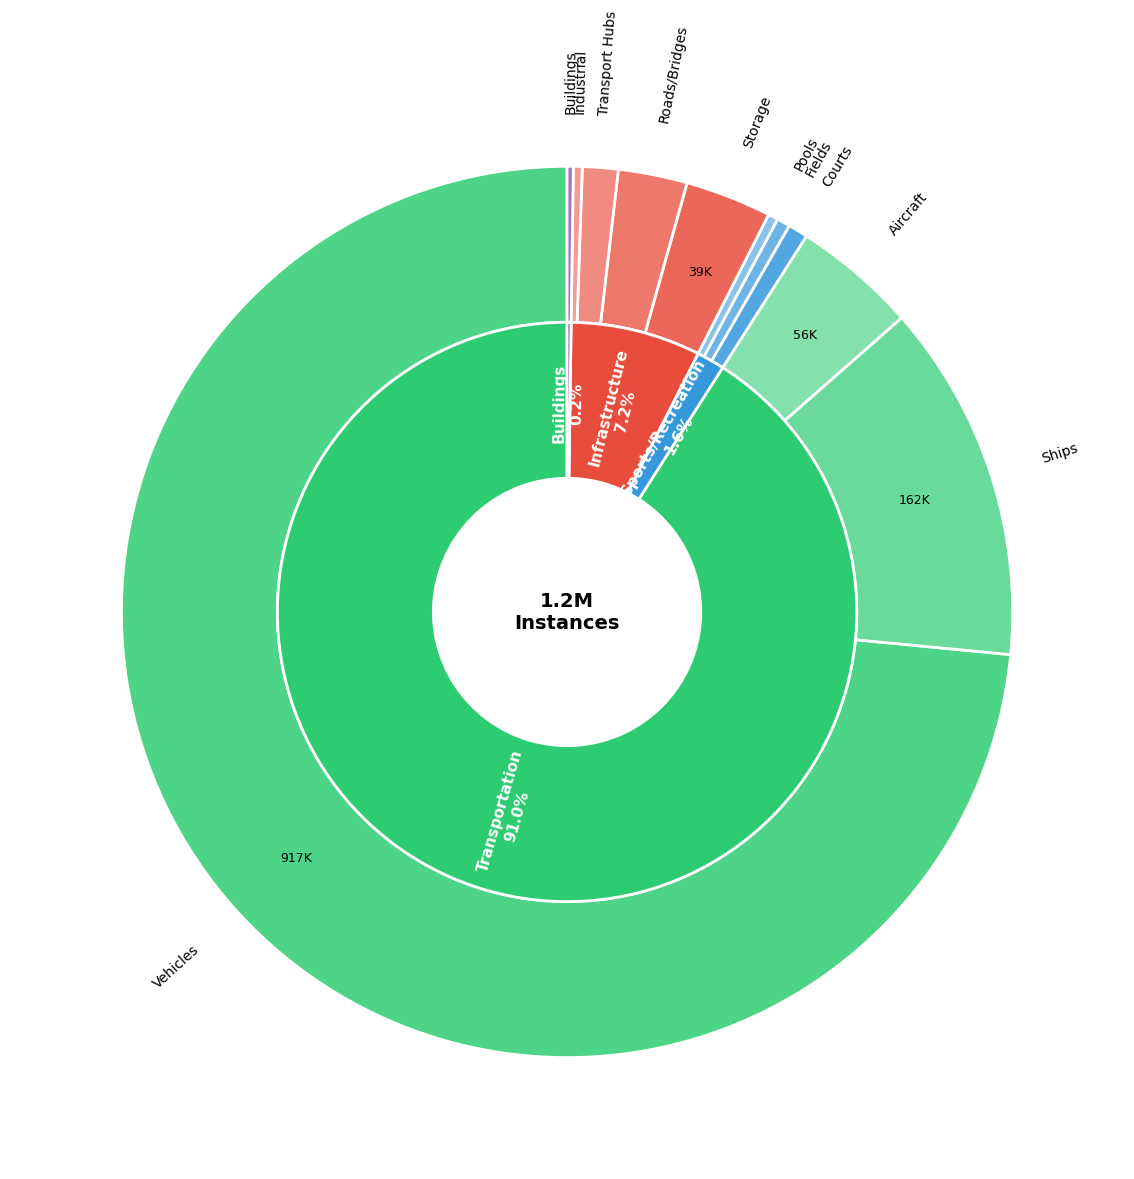


Figure saved as 'dataset_instances_sunburst.png' and '.pdf'


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Dataset paths
dataset_paths = {
    # 'tiny_dota': '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024_tiny_abb.json',
    'fair1m': '/caa/Homes01/mburges/datasets/FAIR1M/coco_annotations.json',
    'xview': '/caa/Homes01/mburges/datasets/xView/annotations/xView_coco.json',
    'sardet': '/caa/Homes01/mburges/datasets/IOD_Datasets/SARDet-100K/annotations/train_split_corrected.json',
    'dota_v2': '/caa/Homes01/mburges/datasets/IOD_Datasets/DOTA-Tiny-OBB/train1024/DOTA2_train1024.json',
    'ai_tod': '/caa/Homes01/mburges/datasets/IOD_Datasets/AI-TOD/annotations/instances_train2017.json',
    'dior': '/caa/Homes01/mburges/datasets/IOD_Datasets/DIOR/annotations/instances_train2017.json',
}

# Two-level mapping: class -> (main_category, subcategory)
class_to_hierarchy = {
    # Transportation - Aircraft
    'plane': ('Transportation', 'Aircraft'),
    'airplane': ('Transportation', 'Aircraft'),
    'aircraft': ('Transportation', 'Aircraft'),
    'helicopter': ('Transportation', 'Aircraft'),
    'fixed-wing aircraft': ('Transportation', 'Aircraft'),
    'small aircraft': ('Transportation', 'Aircraft'),
    'cargo plane': ('Transportation', 'Aircraft'),
    'boeing737': ('Transportation', 'Aircraft'),
    'boeing747': ('Transportation', 'Aircraft'),
    'boeing777': ('Transportation', 'Aircraft'),
    'boeing787': ('Transportation', 'Aircraft'),
    'a220': ('Transportation', 'Aircraft'),
    'a321': ('Transportation', 'Aircraft'),
    'a330': ('Transportation', 'Aircraft'),
    'a350': ('Transportation', 'Aircraft'),
    'arj21': ('Transportation', 'Aircraft'),
    'c919': ('Transportation', 'Aircraft'),
    'other-airplane': ('Transportation', 'Aircraft'),
    
    # Transportation - Ships
    'ship': ('Transportation', 'Ships'),
    'maritime vessel': ('Transportation', 'Ships'),
    'motorboat': ('Transportation', 'Ships'),
    'sailboat': ('Transportation', 'Ships'),
    'tugboat': ('Transportation', 'Ships'),
    'barge': ('Transportation', 'Ships'),
    'ferry': ('Transportation', 'Ships'),
    'yacht': ('Transportation', 'Ships'),
    'container ship': ('Transportation', 'Ships'),
    'liquid cargo ship': ('Transportation', 'Ships'),
    'passenger ship': ('Transportation', 'Ships'),
    'dry cargo ship': ('Transportation', 'Ships'),
    'fishing boat': ('Transportation', 'Ships'),
    'engineering ship': ('Transportation', 'Ships'),
    'warship': ('Transportation', 'Ships'),
    'other-ship': ('Transportation', 'Ships'),
    
    # Transportation - Vehicles
    'vehicle': ('Transportation', 'Vehicles'),
    'small-vehicle': ('Transportation', 'Vehicles'),
    'large-vehicle': ('Transportation', 'Vehicles'),
    'passenger vehicle': ('Transportation', 'Vehicles'),
    'bus': ('Transportation', 'Vehicles'),
    'pickup truck': ('Transportation', 'Vehicles'),
    'utility truck': ('Transportation', 'Vehicles'),
    'truck': ('Transportation', 'Vehicles'),
    'cargo truck': ('Transportation', 'Vehicles'),
    'truck tractor': ('Transportation', 'Vehicles'),
    'trailer': ('Transportation', 'Vehicles'),
    'truck w/flatbed': ('Transportation', 'Vehicles'),
    'truck w/liquid': ('Transportation', 'Vehicles'),
    'crane truck': ('Transportation', 'Vehicles'),
    'railway vehicle': ('Transportation', 'Vehicles'),
    'passenger car': ('Transportation', 'Vehicles'),
    'tank car': ('Transportation', 'Vehicles'),
    'locomotive': ('Transportation', 'Vehicles'),
    'small car': ('Transportation', 'Vehicles'),
    'van': ('Transportation', 'Vehicles'),
    'tractor': ('Transportation', 'Vehicles'),
    'other-vehicle': ('Transportation', 'Vehicles'),
    'dump truck': ('Transportation', 'Vehicles'),
    'engineering vehicle': ('Transportation', 'Vehicles'),
    'excavator': ('Transportation', 'Vehicles'),
    'haul truck': ('Transportation', 'Vehicles'),
    'scraper/tractor': ('Transportation', 'Vehicles'),
    'front loader/bulldozer': ('Transportation', 'Vehicles'),
    'cement mixer': ('Transportation', 'Vehicles'),
    'ground grader': ('Transportation', 'Vehicles'),
    'car': ('Transportation', 'Vehicles'),
    
    # Sports/Recreation - Courts
    'tennis-court': ('Sports/Recreation', 'Courts'),
    'tenniscourt': ('Sports/Recreation', 'Courts'),
    'tennis court': ('Sports/Recreation', 'Courts'),
    'basketball-court': ('Sports/Recreation', 'Courts'),
    'basketballcourt': ('Sports/Recreation', 'Courts'),
    'basketball court': ('Sports/Recreation', 'Courts'),
    
    # Sports/Recreation - Fields
    'baseball-diamond': ('Sports/Recreation', 'Fields'),
    'baseballfield': ('Sports/Recreation', 'Fields'),
    'baseball field': ('Sports/Recreation', 'Fields'),
    'soccer-ball-field': ('Sports/Recreation', 'Fields'),
    'football field': ('Sports/Recreation', 'Fields'),
    'ground-track-field': ('Sports/Recreation', 'Fields'),
    'groundtrackfield': ('Sports/Recreation', 'Fields'),
    'golffield': ('Sports/Recreation', 'Fields'),
    'stadium': ('Sports/Recreation', 'Fields'),
    
    # Sports/Recreation - Pools
    'swimming-pool': ('Sports/Recreation', 'Pools'),
    'swimming pool': ('Sports/Recreation', 'Pools'),
    
    # Infrastructure - Transport Hubs
    'airport': ('Infrastructure', 'Transport Hubs'),
    'harbor': ('Infrastructure', 'Transport Hubs'),
    'helipad': ('Infrastructure', 'Transport Hubs'),
    'trainstation': ('Infrastructure', 'Transport Hubs'),
    
    # Infrastructure - Storage
    'storage-tank': ('Infrastructure', 'Storage'),
    'storagetank': ('Infrastructure', 'Storage'),
    'storage tank': ('Infrastructure', 'Storage'),
    'tank': ('Infrastructure', 'Storage'),
    'dam': ('Infrastructure', 'Storage'),
    
    # Infrastructure - Roads/Bridges
    'bridge': ('Infrastructure', 'Roads/Bridges'),
    'overpass': ('Infrastructure', 'Roads/Bridges'),
    'roundabout': ('Infrastructure', 'Roads/Bridges'),
    'intersection': ('Infrastructure', 'Roads/Bridges'),
    'expressway-service-area': ('Infrastructure', 'Roads/Bridges'),
    'expressway-toll-station': ('Infrastructure', 'Roads/Bridges'),
    
    # Infrastructure - Industrial
    'container-crane': ('Infrastructure', 'Industrial'),
    'tower crane': ('Infrastructure', 'Industrial'),
    'reach stacker': ('Infrastructure', 'Industrial'),
    'mobile crane': ('Infrastructure', 'Industrial'),
    'windmill': ('Infrastructure', 'Industrial'),
    'wind-mill': ('Infrastructure', 'Industrial'),
    'chimney': ('Infrastructure', 'Industrial'),
    'vehicle lot': ('Infrastructure', 'Industrial'),
    
    # Buildings
    'building': ('Buildings', 'Buildings'),
    'aircraft hangar': ('Buildings', 'Buildings'),
    'damaged building': ('Buildings', 'Buildings'),
    'facility': ('Buildings', 'Buildings'),
    'construction site': ('Buildings', 'Buildings'),
    'hut/tent': ('Buildings', 'Buildings'),
    
    # Other
    'person': ('Other', 'Other'),
}

def load_coco_json(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    cat_id_to_name = {}
    for cat in data.get('categories', []):
        cat_id_to_name[cat['id']] = cat['name']
    return cat_id_to_name, data.get('annotations', [])

def count_instances_per_category(cat_id_to_name, annotations):
    counts = defaultdict(int)
    for ann in annotations:
        cat_id = ann['category_id']
        if cat_id in cat_id_to_name:
            cat_name = cat_id_to_name[cat_id]
            counts[cat_name] += 1
    return counts

def map_to_hierarchy(category_counts):
    hierarchy_counts = defaultdict(lambda: defaultdict(int))
    unmapped = []
    for cat_name, count in category_counts.items():
        cat_lower = cat_name.lower().strip()
        if cat_lower in class_to_hierarchy:
            main_cat, sub_cat = class_to_hierarchy[cat_lower]
            hierarchy_counts[main_cat][sub_cat] += count
        else:
            unmapped.append((cat_name, count))
            hierarchy_counts['Other']['Other'] += count
    return hierarchy_counts, unmapped

# Aggregate counts from all datasets
total_hierarchy_counts = defaultdict(lambda: defaultdict(int))
all_unmapped = []

print("Loading datasets and counting instances...")
print("=" * 60)

for dataset_name, json_path in dataset_paths.items():
    try:
        cat_id_to_name, annotations = load_coco_json(json_path)
        category_counts = count_instances_per_category(cat_id_to_name, annotations)
        hierarchy_counts, unmapped = map_to_hierarchy(category_counts)
        
        for main_cat, subcats in hierarchy_counts.items():
            for sub_cat, count in subcats.items():
                total_hierarchy_counts[main_cat][sub_cat] += count
        
        total_instances = sum(category_counts.values())
        print(f"{dataset_name}: {total_instances:,} instances, {len(cat_id_to_name)} categories")
        
        if unmapped:
            all_unmapped.extend([(dataset_name, cat, cnt) for cat, cnt in unmapped])
            
    except FileNotFoundError:
        print(f"{dataset_name}: FILE NOT FOUND - {json_path}")
    except Exception as e:
        print(f"{dataset_name}: ERROR - {e}")

print("=" * 60)

if all_unmapped:
    print("\nUnmapped categories (added to Other):")
    for ds, cat, cnt in all_unmapped:
        print(f"  {ds}: '{cat}' ({cnt:,} instances)")

if 'Other' in total_hierarchy_counts and sum(total_hierarchy_counts['Other'].values()) == 0:
    del total_hierarchy_counts['Other']

# Print summary
print("\nInstance counts per hierarchy:")
grand_total = 0
for main_cat in ['Transportation', 'Sports/Recreation', 'Infrastructure', 'Buildings', 'Other']:
    if main_cat in total_hierarchy_counts:
        total = sum(total_hierarchy_counts[main_cat].values())
        grand_total += total
        print(f"\n{main_cat}: {total:,} instances")
        for sub, count in sorted(total_hierarchy_counts[main_cat].items(), key=lambda x: -x[1]):
            print(f"  - {sub}: {count:,}")

print(f"\nGrand total: {grand_total:,} instances")

# Define order and colors
main_categories = ['Transportation', 'Sports/Recreation', 'Infrastructure', 'Buildings']
main_colors = {
    'Transportation': '#2ecc71',
    'Sports/Recreation': '#3498db', 
    'Infrastructure': '#e74c3c',
    'Buildings': '#9b59b6'
}

def lighten_color(color, factor=0.3):
    import matplotlib.colors as mcolors
    rgb = mcolors.to_rgb(color)
    return tuple(min(1, c + (1 - c) * factor) for c in rgb)

# Prepare data for sunburst
inner_labels = []
inner_sizes = []
inner_colors = []

outer_labels = []
outer_sizes = []
outer_colors = []

for main_cat in main_categories:
    if main_cat not in total_hierarchy_counts:
        continue
    
    subcats = total_hierarchy_counts[main_cat]
    total = sum(subcats.values())
    
    if total == 0:
        continue
    
    inner_labels.append(main_cat)
    inner_sizes.append(total)
    inner_colors.append(main_colors[main_cat])
    
    sorted_subcats = sorted(subcats.items(), key=lambda x: -x[1])
    base_color = main_colors[main_cat]
    n_subcats = len(sorted_subcats)
    
    for i, (subcat, count) in enumerate(sorted_subcats):
        outer_labels.append(subcat)
        outer_sizes.append(count)
        factor = 0.15 + (i / max(n_subcats, 1)) * 0.4
        outer_colors.append(lighten_color(base_color, factor))

def format_number(n):
    if n >= 1_000_000:
        return f'{n/1_000_000:.1f}M'
    elif n >= 1_000:
        return f'{n/1_000:.0f}K'
    else:
        return str(int(n))

# Create the figure
fig, ax = plt.subplots(figsize=(12, 12))

startangle = 90

# Outer ring (subcategories) - no labels initially
outer_wedges, _ = ax.pie(
    outer_sizes,
    radius=1.0,
    colors=outer_colors,
    wedgeprops=dict(width=0.35, edgecolor='white', linewidth=2),
    startangle=startangle
)

# Add rotated labels for outer ring
for i, wedge in enumerate(outer_wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    
    # Calculate position for label
    label_radius = 1.12
    x = label_radius * np.cos(np.radians(angle))
    y = label_radius * np.sin(np.radians(angle))
    
    # Calculate position for count
    count_radius = 0.82
    x_count = count_radius * np.cos(np.radians(angle))
    y_count = count_radius * np.sin(np.radians(angle))
    
    # Determine rotation angle (keep text readable)
    if 90 < angle < 270:
        rotation = angle + 180
        ha = 'right'
    else:
        rotation = angle
        ha = 'left'
    
    # Add label
    ax.text(x, y, outer_labels[i], ha=ha, va='center',
            rotation=rotation, rotation_mode='anchor', fontsize=10)
    
    # Add count if slice is big enough
    pct = outer_sizes[i] / sum(outer_sizes) * 100
    if pct > 3:
        ax.text(x_count, y_count, format_number(outer_sizes[i]), 
                ha='center', va='center', fontsize=9, color='black')

# Inner ring (main categories) - no labels initially
inner_wedges, _ = ax.pie(
    inner_sizes,
    radius=0.65,
    colors=inner_colors,
    wedgeprops=dict(width=0.35, edgecolor='white', linewidth=2),
    startangle=startangle
)

# Add rotated labels for inner ring
for i, wedge in enumerate(inner_wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    
    # Position for label (inside the wedge)
    label_radius = 0.47
    x = label_radius * np.cos(np.radians(angle))
    y = label_radius * np.sin(np.radians(angle))
    
    # Determine rotation
    if 90 < angle < 270:
        rotation = angle + 180
    else:
        rotation = angle
    
    # Calculate percentage
    pct = inner_sizes[i] / sum(inner_sizes) * 100
    
    # Add label with percentage
    ax.text(x, y, f'{inner_labels[i]}\n{pct:.1f}%', ha='center', va='center',
            rotation=rotation, rotation_mode='anchor', 
            fontsize=11, fontweight='bold', color='white')

# Add center text
total_instances = sum(inner_sizes)
ax.text(0, 0, f'{format_number(total_instances)}\nInstances', ha='center', va='center', 
        fontsize=14, fontweight='bold')

# ax.set_title('Object Instance Distribution in Remote Sensing\nObject Detection Datasets', 
#              fontsize=14, fontweight='bold', pad=20)

ax.set_aspect('equal')
plt.tight_layout()
# plt.savefig('dataset_instances_sunburst.png', dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')
# plt.savefig('dataset_instances_sunburst.pdf', bbox_inches='tight')
plt.show()

print("\nFigure saved as 'dataset_instances_sunburst.png' and '.pdf'")

Plot saved successfully!

Summary Statistics:
  Grand Total (est.): 294.7 PB
  Peak Year: 2023 with 63.5 PB

Per-Mission Totals:
  Sentinel-1: 111.9 PB
  Sentinel-2: 155.2 PB
  Sentinel-3: 20.3 PB
  Sentinel-5P: 6.1 PB
  Sentinel-6: 1.2 PB


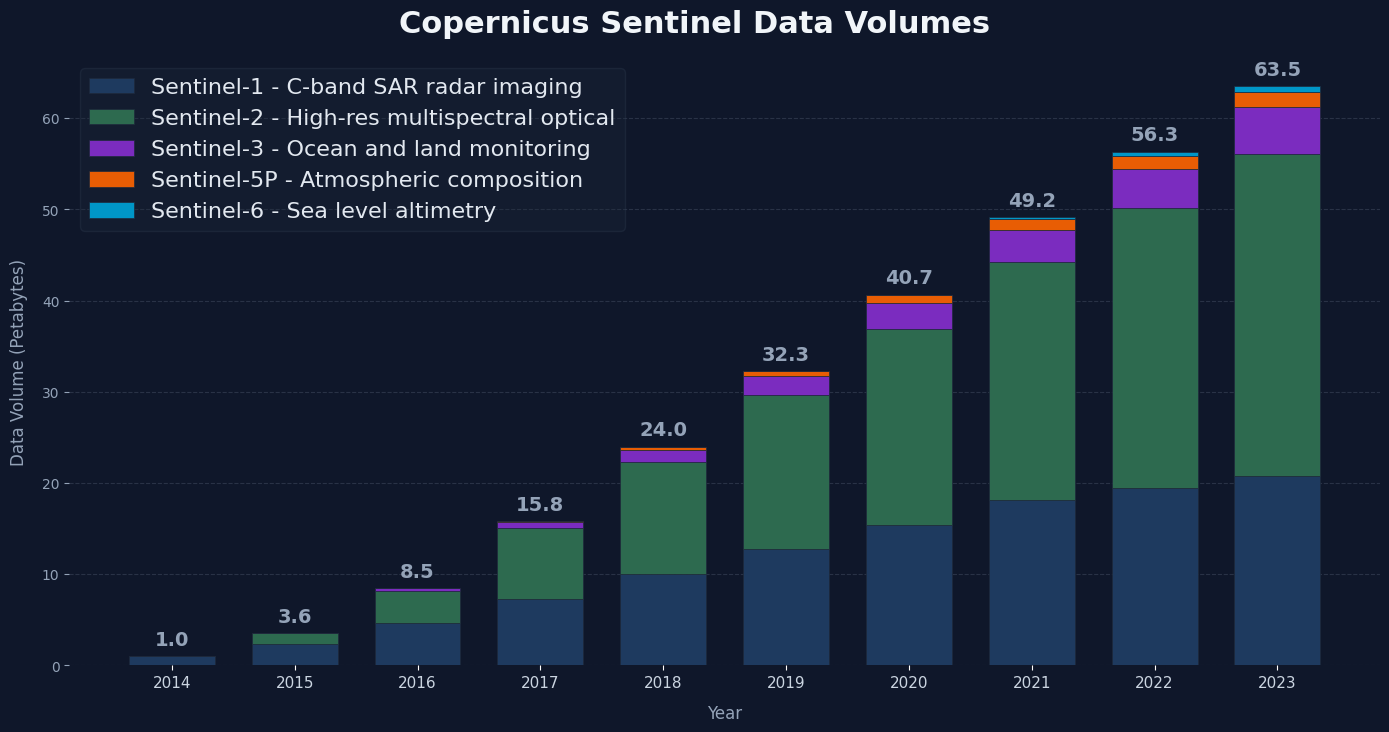

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure with a dark theme
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

# Data: Estimated annual data volumes (in Petabytes) per mission
# Based on ESA Copernicus annual reports and satellite launch dates:
# - Sentinel-1A: Apr 2014, Sentinel-1B: Apr 2016 (failed Dec 2021), Sentinel-1C: Dec 2024
# - Sentinel-2A: Jun 2015, Sentinel-2B: Mar 2017, Sentinel-2C: Sep 2024
# - Sentinel-3A: Feb 2016, Sentinel-3B: Apr 2018
# - Sentinel-5P: Oct 2017
# - Sentinel-6: Nov 2020

years = ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

data = {
    'Sentinel-1': [1.0087,   # 2014: S1A from Apr (partial year)
                   2.3575,   # 2015: S1A full year
                   4.6374,   # 2016: S1A + S1B from Apr
                   7.3348,   # 2017: S1A + S1B full year
                   10.03,   # 2018: S1A + S1B
                   12.72,   # 2019: S1A + S1B
                   15.43,   # 2020: S1A + S1B
                   18.10,   # 2021: S1A + S1B (failed Dec, so ~full year)
                   19.45,   # 2022: S1A only (S1B failed)
                   20.80,   # 2023: S1A only
                   ],  # 2024: S1A + S1C from Dec
    
    'Sentinel-2': [0.0,   # 2014: not launched
                   1.209,   # 2015: S2A from Jun (partial)
                   3.51,   # 2016: S2A full year
                   7.70,   # 2017: S2A + S2B from Mar
                   12.29,   # 2018: S2A + S2B full year
                   16.89,   # 2019: S2A + S2B
                   21.50,   # 2020: S2A + S2B
                   26.10,   # 2021: S2A + S2B
                   30.70,   # 2022: S2A + S2B
                   35.30,   # 2023: S2A + S2B
                   ],  # 2024: S2A + S2B + S2C from Sep
    
    'Sentinel-3': [0.0,   # 2014: not launched
                   0.0,   # 2015: not launched
                   0.32,   # 2016: S3A from Feb
                   0.70,   # 2017: S3A full year
                   1.33,   # 2018: S3A + S3B from Apr
                   2.09,   # 2019: S3A + S3B full year
                   2.84,   # 2020: S3A + S3B
                   3.59,   # 2021: S3A + S3B
                   4.34,   # 2022: S3A + S3B
                   5.10,   # 2023: S3A + S3B
                   ],  # 2024: S3A + S3B
    
    'Sentinel-5P': [0.0,  # 2014-2016: not launched
                    0.0,
                    0.0,
                    0.05,  # 2017: S5P from Oct (partial)
                    0.33,  # 2018: S5P full year
                    0.6,  # 2019-2024: S5P continues
                    0.88,
                    1.15,
                    1.42,
                    1.70,
                    ],
    
    'Sentinel-6': [0.0,   # 2014-2019: not launched
                   0.0,
                   0.0,
                   0.0,
                   0.0,
                   0.0,
                   0.02,  # 2020: S6 from Nov (partial)
                   0.21,  # 2021-2024: S6 continues
                   0.41,
                   0.60,
                   ],
}
# Colors for each mission
colors = {
    'Sentinel-1': '#1e3a5f',
    'Sentinel-2': '#2d6a4f',
    'Sentinel-3': '#7b2cbf',
    'Sentinel-5P': '#e85d04',
    'Sentinel-6': '#0096c7',
}

# Mission descriptions
descriptions = {
    'Sentinel-1': 'C-band SAR radar imaging',
    'Sentinel-2': 'High-res multispectral optical',
    'Sentinel-3': 'Ocean and land monitoring',
    'Sentinel-5P': 'Atmospheric composition',
    'Sentinel-6': 'Sea level altimetry',
}

# Create stacked bar chart
x = np.arange(len(years))
width = 0.7

bottom = np.zeros(len(years))
bars = {}

for mission, values in data.items():
    bars[mission] = ax.bar(x, values, width, label=mission, bottom=bottom, 
                           color=colors[mission], edgecolor='#1e293b', linewidth=0.5)
    bottom += np.array(values)

# Calculate totals for annotation
totals = [sum(data[m][i] for m in data.keys()) for i in range(len(years))]

# Add total labels on top of bars
for i, total in enumerate(totals):
    ax.annotate(f'{total:.1f}', 
                xy=(i, total), 
                ha='center', 
                va='bottom',
                fontsize=14,
                fontweight='bold',
                color='#94a3b8',
                xytext=(0, 5),
                textcoords='offset points')

# Customize the plot
ax.set_xlabel('Year', fontsize=12, color='#94a3b8', labelpad=10)
ax.set_ylabel('Data Volume (Petabytes)', fontsize=12, color='#94a3b8', labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11, color='#cbd5e1')
ax.tick_params(axis='y', colors='#94a3b8')

# Title and subtitle
fig.suptitle('Copernicus Sentinel Data Volumes', 
             fontsize=22, fontweight='bold', color='#f1f5f9', y=0.94)
# ax.set_title('Annual data acquisition by mission (2014-2024) | Estimated from ESA reports',
#              fontsize=11, color='#64748b', pad=15)

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.2, color='#94a3b8')
ax.set_axisbelow(True)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend with descriptions
legend_labels = [f'{m} - {descriptions[m]}' for m in data.keys()]
legend = ax.legend(legend_labels, loc='upper left', frameon=True, 
                   fancybox=True, framealpha=0.3, edgecolor='#334155',
                   fontsize=16, labelcolor='#e2e8f0')
legend.get_frame().set_facecolor('#1e293b')

# Add summary statistics box
grand_total = sum(totals)
# stats_text = (f'Total Archive: ~{grand_total:.1f} PB (est.)\n'
#               f'Active Missions: 5\n'
#               f'Daily Growth: ~20 TB')

# props = dict(boxstyle='round,pad=0.5', facecolor='#1e293b', edgecolor='#334155', alpha=0.9)
# ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, fontsize=10,
#         verticalalignment='top', horizontalalignment='right',
#         bbox=props, color='#e2e8f0', family='monospace')

# Add footnote
# footnote = ('Data Sources: ESA Copernicus Sentinel Data Access Annual Reports (2015-2023).\n'
#             'Values are estimates based on satellite launch dates and reported cumulative totals.\n'
#             'Sentinel-1B failed Dec 2021; Sentinel-1C launched Dec 2024.')
# fig.text(0.5, 0.02, footnote, ha='center', fontsize=8, color='#64748b', style='italic')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12, top=0.88)

# Save the figure
# plt.savefig('/mnt/user-data/outputs/copernicus_sentinel_data_volumes.png', 
#             dpi=150, facecolor='#0f172a', edgecolor='none', bbox_inches='tight')
# plt.savefig('/mnt/user-data/outputs/copernicus_sentinel_data_volumes.pdf', 
#             facecolor='#0f172a', edgecolor='none', bbox_inches='tight')

print("Plot saved successfully!")
print(f"\nSummary Statistics:")
print(f"  Grand Total (est.): {grand_total:.1f} PB")
print(f"  Peak Year: {years[totals.index(max(totals))]} with {max(totals):.1f} PB")
print(f"\nPer-Mission Totals:")
for mission, values in data.items():
    print(f"  {mission}: {sum(values):.1f} PB")

Plot saved successfully!

Summary Statistics (Estimated Annual Acquisition):
  Maxar Total: 1227.0 PB
  Planet Total: 306.0 PB
  Airbus Total: 262.0 PB
  Combined: 1795.0 PB

Reported Total Archives:
  Maxar: ~125 PB (dating back to 1999)
  Planet: ~30+ PB (dating back to 2009)
  Airbus: ~20+ PB (SPOT archive since 1986)


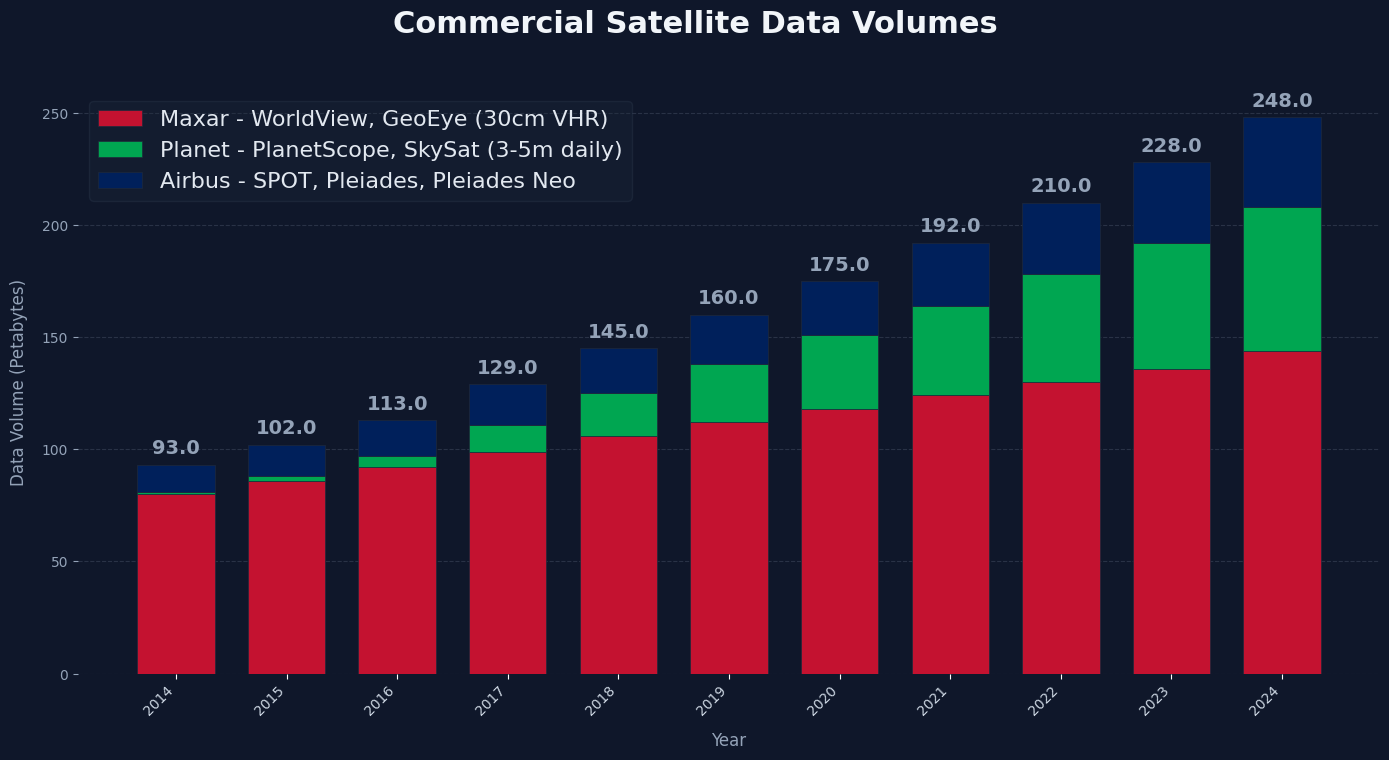

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure with a dark theme
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

# Data: Estimated annual data volumes (in Petabytes) per provider
# Based on publicly available information:
#
# MAXAR (formerly DigitalGlobe):
# - Archive: 110-125+ PB total, adds ~80 TB/day (~29 PB/year currently)
# - IKONOS (1999-2015), QuickBird (2001-2015), WorldView-1 (2007+),
#   GeoEye-1 (2008+), WorldView-2 (2009+), WorldView-3 (2014+),
#   WorldView-4 (2016-2019 failed), WorldView Legion (2024+)
#
# PLANET LABS:
# - Archive: Started 2009 (RapidEye), own satellites 2013+
# - ~30+ PB total, processes 7-10 TB/day
# - RapidEye (2009-2020), Doves (2013+), SkySat (2017+ acquired from Google)
#
# AIRBUS DEFENCE & SPACE:
# - SPOT archive since 1986 (30+ years)
# - Adds ~0.5-2 PB/year currently
# - SPOT 1-5 (1986-2015), SPOT 6/7 (2012+), Pleiades (2011+), Pleiades Neo (2021+)

years = [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

# Estimated annual data acquisition in Petabytes
# Note: These are estimates based on satellite capabilities and public statements
data = {
    'Maxar':  [80.0, 86.0, 92.0, 99.0, 106.0, 112.0, 118.0, 124.0, 130.0, 136.0, 144.0],
    'Planet': [1.0, 2.0, 5.0, 12.0, 19.0, 26.0, 33.0, 40.0, 48.0, 56.0, 64.0],
    'Airbus': [12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 28.0, 32.0, 36.0, 40.0]
}

# Colors for each provider (corporate-inspired colors)
colors = {
    'Maxar': '#c41230',      # Maxar red
    'Planet': '#00a651',     # Planet green
    'Airbus': '#00205b',     # Airbus blue
}

# Provider descriptions
descriptions = {
    'Maxar': 'WorldView, GeoEye (30cm VHR)',
    'Planet': 'PlanetScope, SkySat (3-5m daily)',
    'Airbus': 'SPOT, Pleiades, Pleiades Neo',
}

# Key satellite launches/events for annotation
events = {
    2007: 'WorldView-1',
    2009: 'RapidEye acq.',
    2011: 'Pleiades 1A',
    2013: 'Planet Doves',
    2014: 'WorldView-3',
    2017: 'Planet acq. SkySat',
    2021: 'Pleiades Neo',
    2024: 'WV Legion',
}

# Create stacked bar chart
x = np.arange(len(years))
width = 0.7

bottom = np.zeros(len(years))
bars = {}

for provider, values in data.items():
    bars[provider] = ax.bar(x, values, width, label=provider, bottom=bottom, 
                            color=colors[provider], edgecolor='#1e293b', linewidth=0.5)
    bottom += np.array(values)

# Calculate totals for annotation
totals = [sum(data[p][i] for p in data.keys()) for i in range(len(years))]

# Add total labels on top of bars
for i, total in enumerate(totals):
    if total > 0.5:
        ax.annotate(f'{total:.1f}', 
                    xy=(i, total), 
                    ha='center', 
                    va='bottom',
                    fontsize=14,
                    fontweight='bold',
                    color='#94a3b8',
                    xytext=(0, 5),
                    textcoords='offset points')

# Customize the plot
ax.set_xlabel('Year', fontsize=12, color='#94a3b8', labelpad=10)
ax.set_ylabel('Data Volume (Petabytes)', fontsize=12, color='#94a3b8', labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=10, color='#cbd5e1', rotation=45, ha='right')
ax.tick_params(axis='y', colors='#94a3b8')

# Title and subtitle
fig.suptitle('Commercial Satellite Data Volumes', 
             fontsize=22, fontweight='bold', color='#f1f5f9', y=0.98)
# ax.set_title('Estimated annual data acquisition by provider (2000-2024)',
#              fontsize=11, color='#64748b', pad=15)

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.2, color='#94a3b8')
ax.set_axisbelow(True)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend with descriptions
legend_labels = [f'{p} - {descriptions[p]}' for p in data.keys()]
legend = ax.legend(legend_labels, loc='upper left', frameon=True, 
                   fancybox=True, framealpha=0.3, edgecolor='#334155',
                   fontsize=16, labelcolor='#e2e8f0')
legend.get_frame().set_facecolor('#1e293b')

# Add summary statistics box
maxar_total = sum(data['Maxar'])
planet_total = sum(data['Planet'])
airbus_total = sum(data['Airbus'])
grand_total = maxar_total + planet_total + airbus_total

# stats_text = (f'Reported Archive Sizes:\n'
#               f'Maxar: ~125 PB (since 1999)\n'
#               f'Planet: ~30+ PB (since 2009)\n'
#               f'Airbus: ~20+ PB (since 1986)')

# props = dict(boxstyle='round,pad=0.5', facecolor='#1e293b', edgecolor='#334155', alpha=0.9)
# ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, fontsize=9,
#         verticalalignment='top', horizontalalignment='right',
#         bbox=props, color='#e2e8f0', family='monospace')

# Add key events annotation
# event_y = max(totals) * 0.85
# for year_int, event_name in events.items():
#     try:
#         year_str = str(year_int)
#         if year_str in years:
#             idx = years.index(year_str)
#             ax.annotate(event_name, 
#                        xy=(idx, totals[idx] + 1),
#                        ha='center', va='bottom',
#                        fontsize=7, color='#94a3b8',
#                        rotation=45,
#                        alpha=0.7)
#     except (ValueError, IndexError):
#         pass

# Add footnote
# footnote = ('Data Sources: Public statements, annual reports, and industry analyses.\n'
#             'Values are estimates as commercial providers do not publish detailed volume statistics.\n'
#             'Maxar adds ~80 TB/day; Planet processes 7-10 TB/day; Airbus adds ~0.5-2 PB/year.')
# fig.text(0.5, 0.02, footnote, ha='center', fontsize=8, color='#64748b', style='italic')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.88)

# Save the figure
# plt.savefig('/mnt/user-data/outputs/commercial_satellite_data_volumes.png', 
#             dpi=150, facecolor='#0f172a', edgecolor='none', bbox_inches='tight')
# plt.savefig('/mnt/user-data/outputs/commercial_satellite_data_volumes.pdf', 
#             facecolor='#0f172a', edgecolor='none', bbox_inches='tight')

print("Plot saved successfully!")
print(f"\nSummary Statistics (Estimated Annual Acquisition):")
print(f"  Maxar Total: {maxar_total:.1f} PB")
print(f"  Planet Total: {planet_total:.1f} PB")
print(f"  Airbus Total: {airbus_total:.1f} PB")
print(f"  Combined: {grand_total:.1f} PB")
print(f"\nReported Total Archives:")
print(f"  Maxar: ~125 PB (dating back to 1999)")
print(f"  Planet: ~30+ PB (dating back to 2009)")
print(f"  Airbus: ~20+ PB (SPOT archive since 1986)")

Plot saved successfully!

Summary Statistics (2024):
  USGS EROS:      1,750 TB
  IGN France:     800 TB
  NCAP (UK):      1,400 TB
  Other European: 1,330 TB
  swisstopo:      135 TB
  ─────────────────────────
  TOTAL:          5,415 TB (5.4 PB)


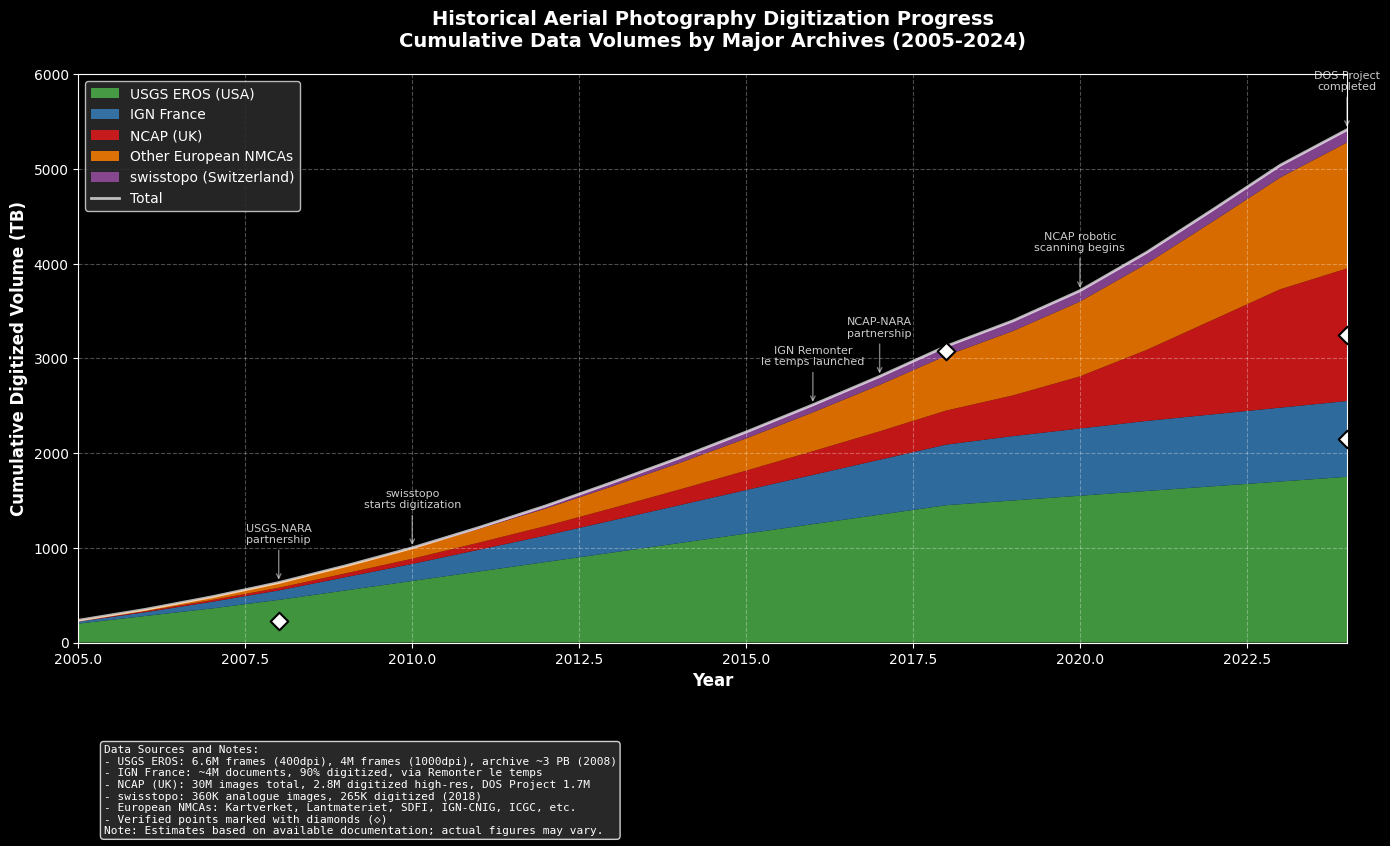

In [5]:
#!/usr/bin/env python3
"""
Historical Aerial Photography Digitization Progress by Major Archives
Cumulative data volumes over time

Data sources:
- NCAP (UK): ncap.org, Edinburgh Impact article, EIDF documentation
- USGS EROS (USA): usgs.gov/centers/eros, NARA press releases
- IGN France: ign.fr, Remonter le temps documentation
- swisstopo (Switzerland): swisstopo.admin.ch, opendata.swiss
- NARA (USA): archives.gov press releases
"""

import matplotlib.pyplot as plt
import numpy as np

# Set dark theme style
plt.style.use('dark_background')

# Define years from 2005 to 2024 (when major digitization programs began/accelerated)
years = np.array([2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
                  2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

# Data estimates in TB (cumulative digitized volumes)
# Based on research findings:

# USGS EROS (USA)
# - Archive reported as ~3 PB total (2008 press release with NARA)
# - 6.6M frames at medium res (~50-100 MB) = ~400 TB
# - 4M frames at high res (~200-500 MB) = ~1200 TB
# - Phoenix scanners built from discarded parts, ongoing scanning
# - Earlier start (1990s-2000s), steady progress
usgs_eros = np.array([
    200, 280, 360, 450, 550, 650, 750, 850, 950, 1050,  # 2005-2014
    1150, 1250, 1350, 1450, 1500, 1550, 1600, 1650, 1700, 1750  # 2015-2024
])

# IGN France
# - ~4 million maps and aerial photographs
# - 90% digitized as of recent years
# - Remonter le temps launched 2016
# - Digitization started ~2007
# - Estimated ~800 TB total when complete
ign_france = np.array([
    20, 40, 70, 100, 140, 180, 230, 280, 340, 400,  # 2005-2014
    460, 520, 580, 640, 680, 710, 740, 760, 780, 800  # 2015-2024 (90% by 2024)
])

# NCAP (UK)
# - 30 million images total
# - 2.8 million digitized to high resolution format (recent)
# - Full collection ~15 PB unoptimized, ~4-7.5 PB optimized
# - Current digitized: ~2.8M x 0.5GB = ~1,400 TB
# - DOS Project (1.7M images) completed 2021-2024
# - Robotic scanning started ~2020
# - Earlier manual scanning was slow (100-200/day)
ncap_uk = np.array([
    5, 10, 18, 28, 40, 55, 75, 100, 130, 165,  # 2005-2014 (slow manual)
    205, 250, 300, 360, 430, 550, 750, 1000, 1250, 1400  # 2015-2024 (acceleration with robots)
])

# swisstopo (Switzerland)
# - ~360,000 analogue aerial photographs
# - 265,000 digitized as of 2018
# - Digitization started 2010
# - Each image ~300-500 MB
# - Total digitized ~80-130 TB
swisstopo = np.array([
    0, 0, 0, 0, 0, 5, 15, 28, 42, 55,  # 2005-2014 (started 2010)
    68, 80, 90, 100, 108, 115, 120, 125, 130, 135  # 2015-2024
])

# Other European NMCAs (combined estimate)
# Includes: Norway (Kartverket), Sweden (Lantmateriet), Denmark (SDFI),
# Spain (IGN-CNIG), Italy (AFN-ICCD), Catalonia (ICGC ~2M images), Germany, etc.
# Based on EuroSDR workshops showing increasing activity
other_european = np.array([
    10, 20, 35, 55, 80, 110, 145, 185, 230, 280,  # 2005-2014
    340, 410, 490, 580, 680, 790, 910, 1040, 1180, 1330  # 2015-2024
])

# Verified data points (for marking on plot)
verified_points = {
    'USGS EROS 2008': (2008, 450, '~3 PB total archive'),
    'swisstopo 2018': (2018, 100, '265K images'),
    'NCAP 2024': (2024, 1400, '2.8M images'),
    'IGN 2024': (2024, 800, '~90% digitized'),
}

# Create figure
fig, ax = plt.subplots(figsize=(14, 9))

# Colors for each agency
colors = {
    'USGS EROS (USA)': '#4DAF4A',     # Green
    'IGN France': '#377EB8',           # Blue
    'NCAP (UK)': '#E41A1C',           # Red
    'Other European NMCAs': '#FF7F00', # Orange
    'swisstopo (Switzerland)': '#984EA3'  # Purple
}

# Create stacked area plot
ax.stackplot(years, 
             usgs_eros, ign_france, ncap_uk, other_european, swisstopo,
             labels=['USGS EROS (USA)', 'IGN France', 'NCAP (UK)', 
                    'Other European NMCAs', 'swisstopo (Switzerland)'],
             colors=[colors['USGS EROS (USA)'], colors['IGN France'], 
                    colors['NCAP (UK)'], colors['Other European NMCAs'],
                    colors['swisstopo (Switzerland)']],
             alpha=0.85)

# Calculate totals for annotation
totals = usgs_eros + ign_france + ncap_uk + other_european + swisstopo

# Add total line
ax.plot(years, totals, 'w-', linewidth=2, alpha=0.7, label='Total')

# Add verified data points
for key, (year, value, label) in verified_points.items():
    # Calculate cumulative y position for the marker
    if 'USGS' in key:
        y_pos = usgs_eros[years == year][0] / 2
    elif 'IGN' in key:
        y_pos = usgs_eros[years == year][0] + ign_france[years == year][0] / 2
    elif 'NCAP' in key:
        y_pos = usgs_eros[years == year][0] + ign_france[years == year][0] + ncap_uk[years == year][0] / 2
    elif 'swisstopo' in key:
        y_pos = totals[years == year][0] - swisstopo[years == year][0] / 2
    
    ax.scatter(year, y_pos, marker='D', s=80, c='white', edgecolors='black', 
               linewidths=1.5, zorder=5)

# Formatting
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Digitized Volume (TB)', fontsize=12, fontweight='bold')
ax.set_title('Historical Aerial Photography Digitization Progress\nCumulative Data Volumes by Major Archives (2005-2024)', 
             fontsize=14, fontweight='bold', pad=20)

# Set axis limits
ax.set_xlim(2005, 2024)
ax.set_ylim(0, 6000)

# Add gridlines
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
legend = ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
legend.get_frame().set_facecolor('#2a2a2a')

# Add annotations for key milestones
milestones = [
    (2008, 'USGS-NARA\npartnership'),
    (2010, 'swisstopo\nstarts digitization'),
    (2016, 'IGN Remonter\nle temps launched'),
    (2017, 'NCAP-NARA\npartnership'),
    (2020, 'NCAP robotic\nscanning begins'),
    (2024, 'DOS Project\ncompleted'),
]

for year, text in milestones:
    y_pos = totals[years == year][0] if year in years else 0
    ax.annotate(text, xy=(year, y_pos), xytext=(year, y_pos + 400),
                fontsize=8, ha='center', va='bottom',
                arrowprops=dict(arrowstyle='->', color='white', alpha=0.5),
                color='white', alpha=0.8)

# Add data source notes
source_text = """Data Sources and Notes:
- USGS EROS: 6.6M frames (400dpi), 4M frames (1000dpi), archive ~3 PB (2008)
- IGN France: ~4M documents, 90% digitized, via Remonter le temps
- NCAP (UK): 30M images total, 2.8M digitized high-res, DOS Project 1.7M
- swisstopo: 360K analogue images, 265K digitized (2018)
- European NMCAs: Kartverket, Lantmateriet, SDFI, IGN-CNIG, ICGC, etc.
- Verified points marked with diamonds (◇)
Note: Estimates based on available documentation; actual figures may vary."""

ax.text(0.02, -0.18, source_text, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#333333', alpha=0.8))

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.28)

# Save figures
# plt.savefig('/home/claude/aerial_digitization_progress.png', dpi=150, 
#             bbox_inches='tight', facecolor='#1a1a1a', edgecolor='none')
# plt.savefig('/home/claude/aerial_digitization_progress.pdf', 
#             bbox_inches='tight', facecolor='#1a1a1a', edgecolor='none')

print("Plot saved successfully!")
print(f"\nSummary Statistics (2024):")
print(f"  USGS EROS:      {usgs_eros[-1]:,} TB")
print(f"  IGN France:     {ign_france[-1]:,} TB")
print(f"  NCAP (UK):      {ncap_uk[-1]:,} TB")
print(f"  Other European: {other_european[-1]:,} TB")
print(f"  swisstopo:      {swisstopo[-1]:,} TB")
print(f"  ─────────────────────────")
print(f"  TOTAL:          {totals[-1]:,} TB ({totals[-1]/1000:.1f} PB)")

Loaded image: 8470x10292


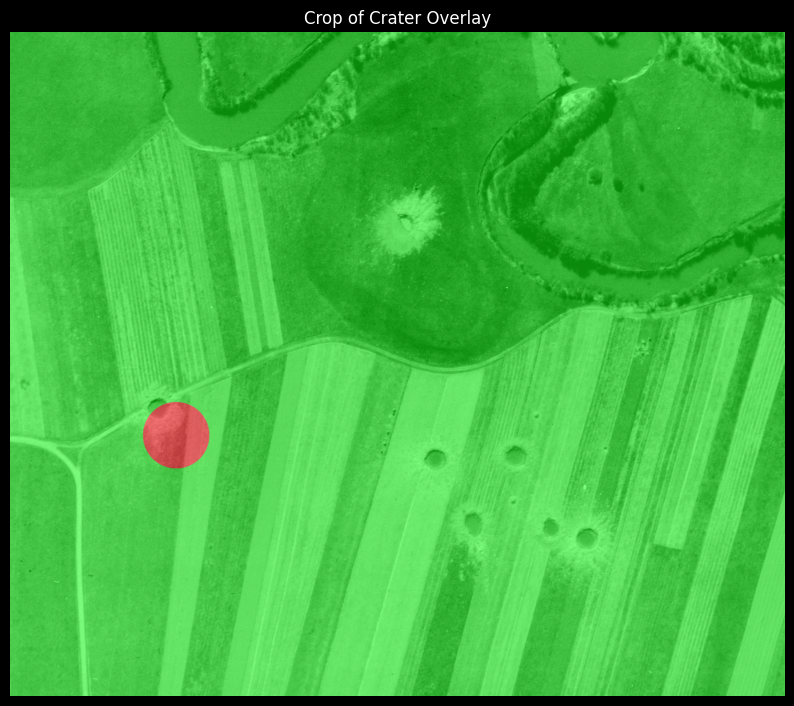

In [6]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

# 1. Setup paths and parameters
image_path = "/caa/Homes01/mburges/ICCV_AL4FM/datasets/1945-04-01_683-1088_4109.jpg"
# Coordinates (X, Y)

fixed_radius = 150
alpha = 0.5

# 2. Load Image (using OpenCV for speed with large arrays)
# Note: OpenCV loads as BGR, so we convert to RGB for consistency
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Could not load image at {image_path}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape
print(f"Loaded image: {w}x{h}")

# 3. Create the Mask
# Initialize a full Green mask: (Height, Width, 3 Channels)
mask = np.full((h, w, 3), (0, 255, 0), dtype=np.uint8)

crater_points = np.array([
    [5925, 6930], [5742, 6823], [6284, 6906],
    [6081, 7256], [6454, 7184], [6649, 7215],
    [5734, 5897]
])

crater_points = np.array([
    [4750, 6823]
])

# Draw Red filled circles for each crater
# cv2.circle(img, center, radius, color, thickness=-1 for filled)
for point in crater_points:
    cv2.circle(mask, (int(point[0]), int(point[1])), fixed_radius, (255, 0, 0), -1)

# 4. Blend Image and Mask
# Formula: src1 * alpha + src2 * beta + gamma
# Here: image * 0.5 + mask * 0.5 + 0
overlaid_image = cv2.addWeighted(image, 1 - alpha, mask, alpha, 0)

# 5. Save or Display
# To save the full-res output:
# output_path = "crater_overlay_result.jpg"
# # Convert back to BGR for saving
# cv2.imwrite(output_path, cv2.cvtColor(overlaid_image, cv2.COLOR_RGB2BGR))
# print(f"Saved overlay to {output_path}")

# To display a crop (e.g., around the main cluster) to check results:
plt.figure(figsize=(10, 10))
# Crop around approx X=6000, Y=7000
plt.imshow(overlaid_image[5000:8000, 4000:7500])
plt.axis('off')
plt.title("Crop of Crater Overlay")
plt.show()